<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/Explainable%20Deep%20Learning%20for%20Cancer%20Survival%20Prediction%3A%20Integrating%20DeepSurv%2C%20SHAP%20Feature%20Attribution%2C%20and%20Pathway%20Enrichment%20Analysis%20for%20Biomarker%20Discovery/notebook23386a3644.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

g65ashaharier21031_genedata_path = kagglehub.dataset_download('g65ashaharier21031/genedata')
g65ashaharier21031_myresearch_path = kagglehub.dataset_download('g65ashaharier21031/myresearch')

print('Data source import complete.')


In [ ]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
# import shutil
# import os

# # ফাইলগুলো ওয়ার্কিং ডিরেক্টরিতে কপি করুন
# shutil.copy("/kaggle/input/datasets/g65ashaharier21031/genedata/gene.txt", "/kaggle/working/gene.txt")

# # এখন ওয়ার্কিং ডিরেক্টরিতে থাকা ফাইলটি ডিলিট করতে চাইলে:
# if os.path.exists("/kaggle/working/gene.txt"):
#     os.remove("/kaggle/working/gene.txt")
#     print("ওয়ার্কিং ডিরেক্টরি থেকে ফাইলটি সফলভাবে রিমুভ হয়েছে।")

In [ ]:
import numpy as np
import pandas as pd
import os

In [ ]:
BASE = "/kaggle/input/datasets/g65ashaharier21031/myresearch"

In [ ]:

# ── Load all four data files ──────────────────────────────────────────────────

gene_list = pd.read_csv(
    "/kaggle/input/datasets/g65ashaharier21031/genedata/gene.txt",
    header=None, names=["gene_id"]
)

In [ ]:
gene_list.head(3)

,gene_id
Gene stable ID,Gene name
ENSG00000210049,MT-TF
ENSG00000211459,MT-RNR1


In [ ]:
print(gene_list.columns)
print(gene_list.index)

Index(['gene_id'], dtype='object')
Index(['Gene stable ID', 'ENSG00000210049', 'ENSG00000211459',
       'ENSG00000210077', 'ENSG00000210082', 'ENSG00000209082',
       'ENSG00000198888', 'ENSG00000210100', 'ENSG00000210107',
       'ENSG00000210112',
       ...
       'ENSG00000126709', 'ENSG00000142910', 'ENSG00000059588',
       'ENSG00000142864', 'ENSG00000122482', 'ENSG00000173372',
       'ENSG00000164007', 'ENSG00000221986', 'ENSG00000203705',
       'ENSG00000132688'],
      dtype='object', length=86412)


In [ ]:
gene_list = gene_list.reset_index()

In [ ]:
gene_list.columns = ["gene_id", "gene_symbol"]
gene_list = gene_list.iloc[1:, :]
# gene_list['gene_symbol'].duplicated().sum()

In [ ]:
gene_list.head(4)

,gene_id,gene_symbol
7,ENSG00000210100,MT-TI
8,ENSG00000210107,MT-TQ
9,ENSG00000210112,MT-TM
10,ENSG00000198763,MT-ND2


In [ ]:
gene_list_sorted = gene_list.copy().reset_index(drop=True)
gene_list_sorted

,gene_id,gene_symbol
0,ENSG00000210100,MT-TI
1,ENSG00000210107,MT-TQ
2,ENSG00000210112,MT-TM
3,ENSG00000198763,MT-ND2
4,ENSG00000210117,MT-TW
...,...,...
86400,ENSG00000173372,C1QA
86401,ENSG00000164007,CLDN19
86402,ENSG00000221986,MYBPHL
86403,ENSG00000203705,TATDN3


# clinical data load

In [ ]:
# ✅ Fix: use latin-1 encoding (handles 0xa0 and similar legacy bytes)
clinical = pd.read_csv(
    f"{BASE}/clinical_PANCAN_patient_with_followup.tsv",
    sep="\t",
    low_memory=False,
    encoding="latin-1"          # <── key fix
)

# EBPlusPlusAdjustPANCAN_IlluminaHiSeq_RNASeqV2 data load

In [ ]:
rna_seq = pd.read_csv(
    f"{BASE}/EBPlusPlusAdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv",
    sep="\t",
    index_col=0,
    encoding="latin-1"          # safeguard for this file too
)

In [ ]:
# print(rna_seq.index.tolist())

In [ ]:
rna_gene_names = rna_seq.index.str.split("|").str[0]
rna_gene_names[20:]

Index(['?', '?', '?', '?', '?', '?', '?', '?', '?', 'A1BG',
       ...
       'ZWILCH', 'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX',
       'ZZEF1', 'ZZZ3'],
      dtype='object', name='gene_id', length=20511)

In [ ]:
valid_mask = rna_gene_names != "?"

rna_seq = rna_seq.loc[valid_mask]
rna_gene_names = rna_gene_names[valid_mask]

# transpose rna

In [ ]:
rna_sample = rna_seq.T

In [ ]:
rna_sample.columns = rna_gene_names.values

In [ ]:
rna_sample = rna_sample.loc[
    :,
    ~rna_sample.columns.duplicated()
]


rna_sample.iloc[:4, :5]

,A1BG,A1CF,A2BP1,A2LD1,A2M
TCGA-OR-A5J1-01A-11R-A29S-07,16.3305,0.0000,17.2911,182.3920,10373.70
TCGA-OR-A5J2-01A-11R-A29S-07,9.5987,0.0000,5.6368,239.1580,9844.91
TCGA-OR-A5J3-01A-11R-A29S-07,20.7377,0.5925,8.8876,138.8830,7201.84
TCGA-OR-A5J5-01A-11R-A29S-07,1696.6600,1.5492,6.1967,63.9349,2939.04


# pancanMiRs_EBadjOnProtocolPlatformWithoutRepsWithUnCorrectMiRs_08_04_16 data load

In [ ]:
mirna_sample = pd.read_csv(
    f"{BASE}/pancanMiRs_EBadjOnProtocolPlatformWithoutRepsWithUnCorrectMiRs_08_04_16.csv",
    index_col=0,
    encoding="latin-1"          # safeguard for this file too
)

In [ ]:

# print("✅ All files loaded successfully!")

# datasets = {
#     "Gene List" : gene_list,
#     "Clinical"  : clinical,
#     "RNA-Seq"   : rna_seq,
#     "miRNA"     : mirna,
# }

# # ── Shape ─────────────────────────────────────────────────────────────────────
# print("\n" + "=" * 60)
# print("SHAPE OF EACH DATASET")
# print("=" * 60)
# for name, df in datasets.items():
#     print(f"  {name:12s} → {df.shape[0]:>7,} rows  ×  {df.shape[1]:>6,} columns")


# shape

In [ ]:
print(f'rna_sample= {rna_sample.shape}')
print(f'clinical_sample ={clinical.shape}')
print(f'mirna_sample = {mirna_sample.shape}')

rna_sample= (11069, 20502)
clinical_sample =(10956, 746)
mirna_sample = (743, 10825)


# sample

In [ ]:
rna_sample.iloc[:4, :10]

,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1,A4GALT,A4GNT,AAA1,AAAS
TCGA-OR-A5J1,16.3305,0.0000,17.2911,182.3920,10373.70,54.7550,190.6820,0.0000,0.0,2225.26
TCGA-OR-A5J2,9.5987,0.0000,5.6368,239.1580,9844.91,0.0000,198.8990,0.0000,0.0,1509.46
TCGA-OR-A5J3,20.7377,0.5925,8.8876,138.8830,7201.84,1.7775,75.2481,2.3700,0.0,1259.67
TCGA-OR-A5J5,1696.6600,1.5492,6.1967,63.9349,2939.04,49.5740,374.9030,0.7746,0.0,2993.80


In [ ]:
clinical.iloc[:3, :5]

,bcr_patient_uuid,bcr_patient_barcode,acronym,gender,vital_status
0,B3164F7B-C826-4E08-9EE6-8FF96D29B913,TCGA-OR-A5J1,ACC,MALE,Dead
1,8E7C2E31-D085-4B75-A970-162526DD07A0,TCGA-OR-A5J2,ACC,FEMALE,Dead
2,DFD687BC-6E69-42F7-AF94-D17FC150D1A1,TCGA-OR-A5J3,ACC,FEMALE,Alive


In [ ]:
mirna_sample = mirna_sample.T
mirna_sample.iloc[:3, :50]

Genes,hsa-let-7a-2-3p,hsa-let-7a-3p,hsa-let-7a-5p,hsa-let-7b-3p,hsa-let-7b-5p,hsa-let-7c-3p,hsa-let-7c-5p,hsa-let-7d-3p,hsa-let-7d-5p,hsa-let-7e-3p,...,hsa-miR-1228-3p,hsa-miR-1229-3p,hsa-miR-124-3p,hsa-miR-1247-3p,hsa-miR-1247-5p,hsa-miR-1248,hsa-miR-1249,hsa-miR-1250-5p,hsa-miR-1251-5p,hsa-miR-1254
TCGA-C4-A0F6-01A-11R-A10V-13,0.980776,32.785934,17787.06993,6.72532,6875.798894,2.241773,598.553468,497.533559,321.974688,34.046932,...,2.381884,3.642882,0.0,17.373743,11.629199,0.140111,3.082438,0.0,0.0,0.700554
TCGA-CU-A0YO-01A-11R-A10V-13,2.750555,62.595962,20816.36637,11.835721,6014.963519,6.001211,1424.704101,340.65206,168.700702,16.336629,...,1.333602,0.833501,0.0,53.344096,13.586074,0.416751,1.166902,0.0,0.0,0.1667
TCGA-BT-A0S7-01A-11R-A10V-13,7.085729,64.480134,64187.20949,41.238943,34652.0489,20.548614,3788.172416,335.296694,250.409661,13.32117,...,1.417146,0.850287,0.0,155.319179,20.690329,0.141715,1.84229,0.283429,0.0,0.992002


In [ ]:
mirna_sample = mirna_sample.drop(columns=['Correction'])

# marge

In [ ]:
rna_sample.index = rna_sample.index.astype(str).str[:12]

mirna_sample.index = mirna_sample.index.astype(str).str[:12]

In [ ]:
[mirna_sample.index, rna_sample.index]

[Index(['TCGA-C4-A0F6', 'TCGA-CU-A0YO', 'TCGA-BT-A0S7', 'TCGA-CU-A0YR',
        'TCGA-BL-A0C8', 'TCGA-C4-A0F0', 'TCGA-BL-A13J', 'TCGA-BT-A0YX',
        'TCGA-CU-A0YN', 'TCGA-CU-A0YR',
        ...
        'TCGA-AG-A020', 'TCGA-AG-A01Y', 'TCGA-AG-A01W', 'TCGA-AG-3726',
        'TCGA-AG-3605', 'TCGA-AG-3584', 'TCGA-AG-3599', 'TCGA-AG-3583',
        'TCGA-AG-3598', 'TCGA-AG-3586'],
       dtype='object', length=10824),
 Index(['TCGA-OR-A5J1', 'TCGA-OR-A5J2', 'TCGA-OR-A5J3', 'TCGA-OR-A5J5',
        'TCGA-OR-A5J6', 'TCGA-OR-A5J7', 'TCGA-OR-A5J8', 'TCGA-OR-A5J9',
        'TCGA-OR-A5JA', 'TCGA-OR-A5JB',
        ...
        'TCGA-CG-4449', 'TCGA-CG-4462', 'TCGA-CG-4465', 'TCGA-CG-4466',
        'TCGA-CG-4469', 'TCGA-CG-4472', 'TCGA-CG-4474', 'TCGA-CG-4475',
        'TCGA-CG-4476', 'TCGA-CG-4477'],
       dtype='object', length=11069)]

In [ ]:
print(clinical_sample.columns[:20])

Index(['bcr_patient_uuid', 'bcr_patient_barcode', 'acronym', 'gender',
       'vital_status', 'days_to_birth', 'days_to_death',
       'days_to_last_followup', 'days_to_initial_pathologic_diagnosis',
       'age_at_initial_pathologic_diagnosis', 'icd_10',
       'tissue_retrospective_collection_indicator', 'icd_o_3_histology',
       'tissue_prospective_collection_indicator',
       'history_of_neoadjuvant_treatment', 'icd_o_3_site', 'tumor_tissue_site',
       'new_tumor_event_after_initial_treatment', 'radiation_therapy', 'race'],
      dtype='object')


In [ ]:
clinical_sample = clinical_sample.assign(
    patient_id=clinical_sample["bcr_patient_barcode"].astype(str).str[:12]
)

In [ ]:
clinical_sample = clinical_sample.set_index(
    "patient_id"
)

In [ ]:
clinical_sample.index

Index(['TCGA-OR-A5J1', 'TCGA-OR-A5J2', 'TCGA-OR-A5J3', 'TCGA-OR-A5J4',
       'TCGA-OR-A5J5', 'TCGA-OR-A5J6', 'TCGA-OR-A5J7', 'TCGA-OR-A5J8',
       'TCGA-OR-A5J9', 'TCGA-OR-A5JA',
       ...
       'TCGA-HT-7880', 'TCGA-HT-7881', 'TCGA-HT-7882', 'TCGA-HT-7884',
       'TCGA-HT-7902', 'TCGA-HT-8010', 'TCGA-HT-8011', 'TCGA-HT-8012',
       'TCGA-HT-8013', 'TCGA-HT-8015'],
      dtype='object', name='patient_id', length=5000)

In [ ]:
clinical_sample.iloc[:2, :100]

,bcr_patient_uuid,bcr_patient_barcode,acronym,gender,vital_status,days_to_birth,days_to_death,days_to_last_followup,days_to_initial_pathologic_diagnosis,age_at_initial_pathologic_diagnosis,...,kras_mutation_found,death_cause_text,lactate_dehydrogenase_result,days_to_sample_procurement,hbv_test,on_haart_therapy_at_cancer_diagnosis,hcv_test,prior_aids_conditions,on_haart_therapy_prior_to_cancer_diagnosis,kshv_hhv8_test
patient_id,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5J1,B3164F7B-C826-4E08-9EE6-8FF96D29B913,TCGA-OR-A5J1,ACC,MALE,Dead,-21496,1355.0,[Not Available],0,58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-OR-A5J2,8E7C2E31-D085-4B75-A970-162526DD07A0,TCGA-OR-A5J2,ACC,FEMALE,Dead,-16090,1677,[Not Available],0,44,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
clinical_sample['bcr_patient_uuid']

patient_id
TCGA-OR-A5J1    B3164F7B-C826-4E08-9EE6-8FF96D29B913
TCGA-OR-A5J2    8E7C2E31-D085-4B75-A970-162526DD07A0
TCGA-OR-A5J3    DFD687BC-6E69-42F7-AF94-D17FC150D1A1
TCGA-OR-A5J4    5F3E2974-F1DF-47A2-8A8A-29BB525EEEF6
TCGA-OR-A5J5    802DBD0D-EF07-4C91-AB8D-1DD39532E947
                                ...                 
TCGA-HT-8010    114902c7-77b2-42ca-926b-6895e6db5e36
TCGA-HT-8011    58de25d5-8a32-4412-866b-acac2e321bfa
TCGA-HT-8012    9351b1ae-89e6-4091-934f-d50da06cd01d
TCGA-HT-8013    e669a4b7-a494-490a-b78c-e664c59d0697
TCGA-HT-8015    81076cfb-f9d7-4add-b696-6eab0bad7945
Name: bcr_patient_uuid, Length: 5000, dtype: object

# common patients

In [ ]:
common_patients = (
    rna_sample.index.intersection(mirna_sample.index).intersection(clinical_sample.index)
)
print(f'common columns = {len(common_patients)}')

common columns = 4191


# final common column

In [ ]:
rna_sample = rna_sample.loc[common_patients]

mirna_sample = mirna_sample.loc[common_patients]

clinical_sample = clinical_sample.loc[common_patients]

In [ ]:
print(rna_sample.shape)
print(mirna_sample.shape)
print(clinical_sample.shape)

(4581, 20502)
(4532, 743)
(4191, 745)


In [ ]:
print("RNA duplicates:", rna_sample.index.duplicated().sum())
print("miRNA duplicates:", mirna_sample.index.duplicated().sum())
print("Clinical duplicates:", clinical_sample.index.duplicated().sum())

RNA duplicates: 390
miRNA duplicates: 341
Clinical duplicates: 0


In [ ]:
rna_sample = rna_sample[~rna_sample.index.duplicated(keep="first")]

mirna_sample = mirna_sample[~mirna_sample.index.duplicated(keep="first")]

clinical_sample = clinical_sample[~clinical_sample.index.duplicated(keep="first")]

In [ ]:
rna_sample.head(3)

,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1,A4GALT,A4GNT,AAA1,AAAS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
TCGA-OR-A5J1,16.3305,0.0000,17.2911,182.392,10373.70,54.7550,190.6820,0.00,0.0,2225.26,...,183.9580,146.974,20.6532,351.585,1050.910,0.4803,648.415,1841.02,1157.54,596.062
TCGA-OR-A5J2,9.5987,0.0000,5.6368,239.158,9844.91,0.0000,198.8990,0.00,0.0,1509.46,...,264.1250,438.464,57.1735,279.023,2979.870,31.4052,1166.020,3059.99,1895.99,801.637
TCGA-OR-A5J3,20.7377,0.5925,8.8876,138.883,7201.84,1.7775,75.2481,2.37,0.0,1259.67,...,90.6532,190.194,39.6978,495.334,914.827,0.5925,806.399,2655.61,1482.45,437.269


In [ ]:
clinical_sample.head(3)

,bcr_patient_uuid,bcr_patient_barcode,acronym,gender,vital_status,days_to_birth,days_to_death,days_to_last_followup,days_to_initial_pathologic_diagnosis,age_at_initial_pathologic_diagnosis,...,total_bilirubin_upper_limit,platelet_result_count,fibrosis_ishak_score,fetoprotein_outcome_value,fetoprotein_outcome_upper_limit,fetoprotein_outcome_lower_limit,inter_norm_ratio_lower_limit,family_cancer_type_txt,bilirubin_upper_limit,days_to_last_known_alive
TCGA-OR-A5J1,B3164F7B-C826-4E08-9EE6-8FF96D29B913,TCGA-OR-A5J1,ACC,MALE,Dead,-21496,1355.0,[Not Available],0,58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-OR-A5J2,8E7C2E31-D085-4B75-A970-162526DD07A0,TCGA-OR-A5J2,ACC,FEMALE,Dead,-16090,1677,[Not Available],0,44,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-OR-A5J3,DFD687BC-6E69-42F7-AF94-D17FC150D1A1,TCGA-OR-A5J3,ACC,FEMALE,Alive,-8624,[Not Applicable],2091.0,0,23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
mirna_sample.iloc[:3,:100]

Genes,hsa-let-7a-2-3p,hsa-let-7a-3p,hsa-let-7a-5p,hsa-let-7b-3p,hsa-let-7b-5p,hsa-let-7c-3p,hsa-let-7c-5p,hsa-let-7d-3p,hsa-let-7d-5p,hsa-let-7e-3p,...,hsa-miR-132-3p,hsa-miR-132-5p,hsa-miR-133a-3p,hsa-miR-133a-5p,hsa-miR-133b,hsa-miR-1343-3p,hsa-miR-134-3p,hsa-miR-134-5p,hsa-miR-135a-3p,hsa-miR-135a-5p
TCGA-OR-A5J1,1.516652,74.323353,44763.18108,44.861733,16813.80497,12.957247,1607.336927,1858.904645,426.761055,15.929409,...,76.31881,1.350943,3.902254,0.064228,0.313405,0.788103,2.971518,597.416416,3.691185,6.507793
TCGA-OR-A5J2,8.642807,70.369898,16962.87182,43.467068,12641.98418,16.07832,1356.026918,1163.444205,369.333643,43.633804,...,38.467226,0.976013,4.682654,0.140918,2.463981,0.381233,-0.087734,36.903907,7.39397,18.552261
TCGA-OR-A5J3,2.178482,20.622001,25323.37845,40.143282,12057.8123,5.826378,626.051788,271.447393,115.104405,12.466613,...,86.485466,0.847038,1.456161,0.064228,0.549016,0.141418,4.442823,1213.835023,0.651869,13.259352


In [ ]:
obj_cols = mirna_sample.select_dtypes(include=['object']).shape[1]


In [ ]:
merged_df = pd.concat(
    [
        rna_sample,
        mirna_sample,
        clinical_sample
    ],
    axis=1
)

print(merged_df.shape)
merged_df.head()

(4191, 21990)


,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1,A4GALT,A4GNT,AAA1,AAAS,...,total_bilirubin_upper_limit,platelet_result_count,fibrosis_ishak_score,fetoprotein_outcome_value,fetoprotein_outcome_upper_limit,fetoprotein_outcome_lower_limit,inter_norm_ratio_lower_limit,family_cancer_type_txt,bilirubin_upper_limit,days_to_last_known_alive
TCGA-OR-A5J1,16.3305,0.0000,17.2911,182.3920,10373.70,54.7550,190.6820,0.0000,0.0,2225.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-OR-A5J2,9.5987,0.0000,5.6368,239.1580,9844.91,0.0000,198.8990,0.0000,0.0,1509.46,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-OR-A5J3,20.7377,0.5925,8.8876,138.8830,7201.84,1.7775,75.2481,2.3700,0.0,1259.67,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-OR-A5J5,1696.6600,1.5492,6.1967,63.9349,2939.04,49.5740,374.9030,0.7746,0.0,2993.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-OR-A5J6,600.1620,0.0000,4.4709,237.3520,9586.96,1.1177,1556.4200,0.5589,0.0,1186.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='vital_status'>

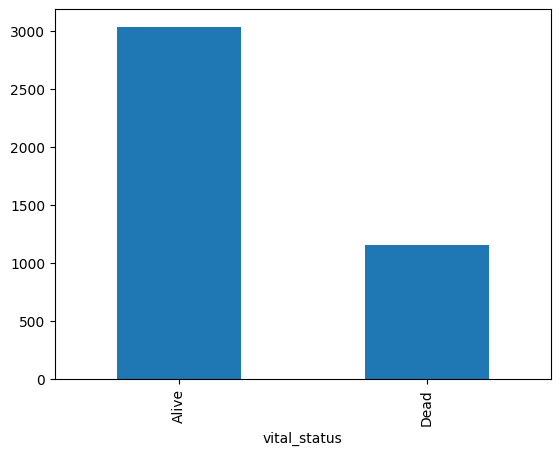

In [ ]:
merged_df["vital_status"].value_counts().plot(kind='bar')

In [ ]:
merged_df["event"] = (
    merged_df["vital_status"] == "Dead"
).astype(int)

In [ ]:
# merged_df["event"].isnull().sum()

In [ ]:
# [merged_df["days_to_last_followup"].value_counts()]

In [ ]:
missing_values = [
    "[Not Available]",
    "[Not Applicable]",
    "Not Available",
    "Not Applicable",
    "NA",
    "na",
    ""
]

merged_df["days_to_death"] = merged_df["days_to_death"].replace(
    missing_values, np.nan
)

merged_df["days_to_last_followup"] = merged_df["days_to_last_followup"].replace(
    missing_values, np.nan
)

In [ ]:
merged_df["days_to_death"]

TCGA-OR-A5J1    1355.0
TCGA-OR-A5J2      1677
TCGA-OR-A5J3       NaN
TCGA-OR-A5J5       365
TCGA-OR-A5J6       NaN
                 ...  
TCGA-Z6-A8JD       NaN
TCGA-Z6-A8JE       NaN
TCGA-Z6-A9VB       NaN
TCGA-Z6-AAPN       NaN
TCGA-ZR-A9CJ     600.0
Name: days_to_death, Length: 4191, dtype: object

In [ ]:
merged_df["days_to_death"] = pd.to_numeric(
    merged_df["days_to_death"],
    errors="coerce"
)

merged_df["days_to_last_followup"] = pd.to_numeric(
    merged_df["days_to_last_followup"],
    errors="coerce"
)

In [ ]:
merged_df["days_to_death"].isnull().sum()

np.int64(3038)

In [ ]:
merged_df["days_to_last_followup"]

TCGA-OR-A5J1       NaN
TCGA-OR-A5J2       NaN
TCGA-OR-A5J3    2091.0
TCGA-OR-A5J5       NaN
TCGA-OR-A5J6    2703.0
                 ...  
TCGA-Z6-A8JD     104.0
TCGA-Z6-A8JE      64.0
TCGA-Z6-A9VB      40.0
TCGA-Z6-AAPN      81.0
TCGA-ZR-A9CJ     551.0
Name: days_to_last_followup, Length: 4191, dtype: float64

In [ ]:
merged_df["event"] = (merged_df["vital_status"] == "Dead").astype(int)

merged_df["time"] = merged_df["days_to_death"].fillna(
    merged_df["days_to_last_followup"]
)

In [ ]:
print(merged_df[["time", "event"]].head())

print(merged_df["event"].value_counts())

                time  event
TCGA-OR-A5J1  1355.0      1
TCGA-OR-A5J2  1677.0      1
TCGA-OR-A5J3  2091.0      0
TCGA-OR-A5J5   365.0      1
TCGA-OR-A5J6  2703.0      0
event
0    3034
1    1157
Name: count, dtype: int64


In [ ]:
X = merged_df.drop(columns=['time', 'event'])
y_event = merged_df['event']
y_time = merged_df['time']

In [ ]:
print(X.shape)
print(y_event.shape)
print(y_time.shape)

(4191, 21990)
(4191,)
(4191,)


In [ ]:
print(y_event.isnull().sum())
print(y_time.isnull().sum())

0
8


In [ ]:
mask = ~y_time.isnull()

X = X[mask]
y_time = y_time[mask]
y_event = y_event[mask]

In [ ]:
print(X.shape)
print(y_event.shape)
print(y_time.shape)

(4183, 21990)
(4183,)
(4183,)


In [ ]:
print(y_event.isnull().sum())
print(y_time.isnull().sum())

0
0


In [ ]:
print("Shape X:", X.shape)
print("Missing values:", X.isnull().sum().sum())
# print("Inf values:", np.isinf(X.values).sum())

Shape X: (4183, 21990)
Missing values: 3370952


In [ ]:
print(X.dtypes.value_counts())

float64    20509
object      1481
Name: count, dtype: int64


In [ ]:
X_num = X.select_dtypes(include=[np.number])

In [ ]:
print("Shape:", X_num.shape)

print("Missing values:", X_num.isnull().sum().sum())

print("Inf values:", np.isinf(X_num.to_numpy()).sum())

Shape: (4183, 20509)
Missing values: 674341
Inf values: 0


In [ ]:
X_num_clean = X_num.dropna(axis=1, how="all")

print("Before:", X_num.shape)
print("After removing empty cols:", X_num_clean.shape)
print(X_num_clean.isnull().sum().sum())

Before: (4183, 20509)
After removing empty cols: (4183, 20505)
657609


In [ ]:
missing_ratio = X_num.isnull().mean()

cols_to_keep = missing_ratio[missing_ratio < 0.9].index

X_num_clean = X_num[cols_to_keep]

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_imputed_array = imputer.fit_transform(X_num_clean)

In [ ]:
X_imputed = pd.DataFrame(
    X_imputed_array,
    columns = X_num_clean.columns,
    index = X_num_clean.index
)

In [ ]:
X_imputed.head(3)

,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1,A4GALT,A4GNT,AAA1,AAAS,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,days_to_death,days_to_last_followup
TCGA-OR-A5J1,16.3305,0.0000,17.2911,182.392,10373.70,54.7550,190.6820,0.00,0.0,2225.26,...,20.6532,351.585,1050.910,0.4803,648.415,1841.02,1157.54,596.062,1355.0,747.0
TCGA-OR-A5J2,9.5987,0.0000,5.6368,239.158,9844.91,0.0000,198.8990,0.00,0.0,1509.46,...,57.1735,279.023,2979.870,31.4052,1166.020,3059.99,1895.99,801.637,1677.0,747.0
TCGA-OR-A5J3,20.7377,0.5925,8.8876,138.883,7201.84,1.7775,75.2481,2.37,0.0,1259.67,...,39.6978,495.334,914.827,0.5925,806.399,2655.61,1482.45,437.269,570.0,2091.0


In [ ]:
# obj_cols = X_imputed.select_dtypes(include=['object']).shape[1]

In [ ]:
X_imputed.isnull().sum().sum()

np.int64(0)

In [ ]:
print(X_imputed.shape)
print(y_event.shape)
print(y_time.shape)

(4183, 20506)
(4183,)
(4183,)


In [ ]:
print(y_event.isnull().sum())
print(y_time.isnull().sum())

0
0


In [ ]:
y_time

TCGA-OR-A5J1    1355.0
TCGA-OR-A5J2    1677.0
TCGA-OR-A5J3    2091.0
TCGA-OR-A5J5     365.0
TCGA-OR-A5J6    2703.0
                 ...  
TCGA-Z6-A8JD     104.0
TCGA-Z6-A8JE      64.0
TCGA-Z6-A9VB      40.0
TCGA-Z6-AAPN      81.0
TCGA-ZR-A9CJ     600.0
Name: time, Length: 4183, dtype: float64

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split

X_train, X_val, time_train, time_val, event_train, event_val = train_test_split(
    X_imputed,
    y_time,
    y_event,
    test_size=0.2,
    random_state=42
)

# StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [ ]:
! pip install PCA

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 kB 9.5 MB/s eta 0:00:00


In [ ]:
# from sklearn.decomposition import PCA

# pca = PCA(n_components=100)

# X_train_pca = pca.fit_transform(X_train_scaled)
# X_val_pca = pca.transform(X_val_scaled)

In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.1)

X_train_reduced = selector.fit_transform(X_train_scaled)
X_val_reduced = selector.transform(X_val_scaled)

In [ ]:
selected_cols = X_train.columns[selector.get_support()]

X_train_reduced = pd.DataFrame(
    X_train_reduced,
    columns=selected_cols,
    index=X_train.index
)

X_val_reduced = pd.DataFrame(
    X_val_reduced,
    columns=selected_cols,
    index=X_val.index
)

In [ ]:
X_train_reduced.head(3)

,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1,A4GALT,A4GNT,AAA1,AAAS,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,days_to_death,days_to_last_followup
TCGA-BP-4759,-0.244951,0.957565,-0.155942,-0.428077,2.134587,-0.301844,1.219042,-0.089253,-0.166851,-0.664494,...,1.769828,-0.404032,-0.249364,-0.488271,0.201042,0.155081,-0.409613,-0.338361,-0.188323,1.396663
TCGA-CV-7252,-0.221724,-0.418324,-0.155942,-0.389583,-0.501714,0.835318,0.059516,-0.142094,0.000891,0.038473,...,-0.846940,-0.784157,-1.721726,-0.616161,-0.141145,2.565687,-0.554588,-0.346762,-0.979184,-0.281752
TCGA-BP-4985,-0.254726,-0.403693,-0.154589,-0.345185,1.415965,-0.301856,-0.098398,-0.058147,1.581282,-0.518448,...,1.931200,0.634117,-1.097045,-0.598101,-0.315877,-0.191369,-0.109867,-0.539711,0.532701,-0.281752


In [ ]:
X_val_reduced.head(4)

,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1,A4GALT,A4GNT,AAA1,AAAS,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,days_to_death,days_to_last_followup
TCGA-DG-A2KL,-0.230968,-0.418324,-0.155942,-0.374291,-0.550380,5.003591,0.070223,-0.119603,-0.166851,-0.188188,...,-0.351262,0.042797,1.139903,0.465292,-0.616745,0.431033,-0.680047,0.177182,-0.188323,0.358628
TCGA-GR-A4D5,0.018534,-0.418324,-0.155942,0.563773,-0.409235,-0.300744,-0.218617,-0.133418,-0.166851,1.560382,...,0.099094,-0.200953,-0.880337,1.113820,-0.819058,1.011866,0.503365,-0.509719,-0.188323,0.288393
TCGA-A2-A4S0,0.327510,-0.418324,-0.154124,-0.480930,-0.304915,-0.301826,-0.756522,-0.066909,-0.166851,0.237411,...,0.604716,0.075399,0.208311,-0.561570,-0.429318,-0.619793,0.803783,1.479613,-0.188323,-0.324099
TCGA-4Z-AA84,1.254221,-0.418324,-0.155942,0.591913,-0.621173,-0.257739,-0.545188,-0.142094,-0.166851,-0.585221,...,-0.723509,-0.621237,-0.268305,1.170441,-0.491910,2.421063,-0.756343,-0.416178,-0.188323,-0.578186


In [ ]:
import torch

device = torch.device("cpu")  # or cuda if stable

X_train_tensor = torch.tensor(
    X_train_reduced.values,
    dtype=torch.float32,
    device=device
)

X_val_tensor = torch.tensor(
    X_val_reduced.values,
    dtype=torch.float32,
    device=device
)

time_train_tensor = torch.tensor(
    time_train.values,
    dtype=torch.float32,
    device=device
)

time_val_tensor = torch.tensor(
    time_val.values,
    dtype=torch.float32,
    device=device
)

event_train_tensor = torch.tensor(
    event_train.values,
    dtype=torch.float32,
    device=device
)

event_val_tensor = torch.tensor(
    event_val.values,
    dtype=torch.float32,
    device=device
)

# DeepSurv Model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [ ]:
class DeepSurv(nn.Module):
    def __init__(self, input_dim):
        super(DeepSurv, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

# Transformer Block

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads=8, dropout=0.1):
        super().__init__()

        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

        self.ff = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)

        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)

        return x

In [ ]:
class TransformerSurv(nn.Module):
    def __init__(self, input_dim, embed_dim=128, num_heads=8, num_layers=2):
        super().__init__()

        # Feature embedding
        self.input_proj = nn.Linear(input_dim, embed_dim)

        # Transformer layers
        self.layers = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads)
            for _ in range(num_layers)
        ])

        # Survival head
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):

        # (batch, features) → (batch, 1, embed_dim)
        x = self.input_proj(x).unsqueeze(1)

        # Transformer encoding
        for layer in self.layers:
            x = layer(x)

        # Pooling (sequence length = 1 here)
        x = x.squeeze(1)

        # Risk score
        return self.head(x)

# LOSS FUNCTION

In [ ]:
def cox_loss(risk, time, event):
    order = torch.argsort(time, descending=True)

    risk = risk[order]
    event = event[order]

    log_cumsum = torch.logcumsumexp(risk, dim=0)

    loss = -torch.sum((risk - log_cumsum) * event)

    denom = torch.sum(event) + 1e-8   # safety

    return loss / denom

# C-INDEX

In [ ]:
!pip install lifelines

In [ ]:
from lifelines.utils import concordance_index


def calculate_c_index(risk, time, event):
    risk = risk.detach().numpy()

    return concordance_index(
        time,
        -risk,
        event
    )

# NN MODEL

In [ ]:
model = DeepSurv(X_train_tensor.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# TransformerSurv MODEL

In [ ]:
model = TransformerSurv(
    input_dim=X_train_tensor.shape[1],
    embed_dim=128,
    num_heads=8,
    num_layers=2
).to(device)

# TRAINING (EARLY STOPPING)

In [ ]:
import copy
import torch

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

epochs = 200
patience = 10

best_val_loss = float("inf")
counter = 0
best_model_state = None
train_loss_list = []
val_loss_list = []

train_cindex_list = []
val_cindex_list = []

val_risk_list = []

for epoch in range(epochs):

    # ==========================
    # TRAIN
    # ==========================
    model.train()

    optimizer.zero_grad()

    # Forward pass
    train_risk = model(X_train_tensor).squeeze()

    # Cox loss
    train_loss = cox_loss(
        train_risk,
        time_train_tensor,
        event_train_tensor
    )



    # Backpropagation
    train_loss.backward()

    # Gradient clipping (helps stability)
    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    # Train C-index
    train_cindex = calculate_c_index(
        train_risk,
        time_train_tensor,
        event_train_tensor
    )

    train_cindex_list.append(train_cindex)

    train_loss_list.append(train_loss.item())

    # ==========================
    # VALIDATION
    # ==========================
    model.eval()

    with torch.no_grad():

        val_risk = model(X_val_tensor).squeeze()

        val_loss = cox_loss(
            val_risk,
            time_val_tensor,
            event_val_tensor
        )

        val_cindex = calculate_c_index(
            val_risk,
            time_val_tensor,
            event_val_tensor
        )


        val_cindex_list.append(val_cindex)
        val_loss_list.append(val_loss.item())
        val_risk_list.append(val_risk.detach().cpu().numpy())

    # ==========================
    # EARLY STOPPING
    # ==========================
    current_val_loss = val_loss.item()

    if current_val_loss < best_val_loss:

        best_val_loss = current_val_loss
        counter = 0

        # Deep copy best weights
        best_model_state = copy.deepcopy(
            model.state_dict()
        )

    else:
        counter += 1

    # ==========================
    # LOGGING
    # ==========================
    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss.item():.4f} | "
        f"Val Loss: {current_val_loss:.4f} | "
        f"Train C-index: {train_cindex:.4f} | "
        f"Val C-index: {val_cindex:.4f}"
    )

    # ==========================
    # EARLY STOP CHECK
    # ==========================
    if counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break


# ==========================
# RESTORE BEST MODEL
# ==========================
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("\nBest model restored ✔")

Epoch [1/200] | Train Loss: 7.2872 | Val Loss: 5.9586 | Train C-index: 0.5083 | Val C-index: 0.6634
Epoch [2/200] | Train Loss: 7.1226 | Val Loss: 5.8617 | Train C-index: 0.6897 | Val C-index: 0.6966
Epoch [3/200] | Train Loss: 6.9898 | Val Loss: 5.8112 | Train C-index: 0.7417 | Val C-index: 0.7168
Epoch [4/200] | Train Loss: 6.9196 | Val Loss: 5.7817 | Train C-index: 0.7632 | Val C-index: 0.7293
Epoch [5/200] | Train Loss: 6.8572 | Val Loss: 5.7728 | Train C-index: 0.7802 | Val C-index: 0.7345
Epoch [6/200] | Train Loss: 6.7820 | Val Loss: 5.7693 | Train C-index: 0.7989 | Val C-index: 0.7372
Epoch [7/200] | Train Loss: 6.7174 | Val Loss: 5.7604 | Train C-index: 0.8114 | Val C-index: 0.7427
Epoch [8/200] | Train Loss: 6.6572 | Val Loss: 5.7443 | Train C-index: 0.8251 | Val C-index: 0.7481
Epoch [9/200] | Train Loss: 6.5826 | Val Loss: 5.7290 | Train C-index: 0.8409 | Val C-index: 0.7519
Epoch [10/200] | Train Loss: 6.5384 | Val Loss: 5.7250 | Train C-index: 0.8489 | Val C-index: 0.7541

In [ ]:
model.eval()

with torch.no_grad():
    risk = model(X_val_tensor).squeeze()

final_cindex = concordance_index(
    time_val,
    -risk.numpy(),
    event_val
)

print("FINAL C-index:", final_cindex)

FINAL C-index: 0.7540789033767971


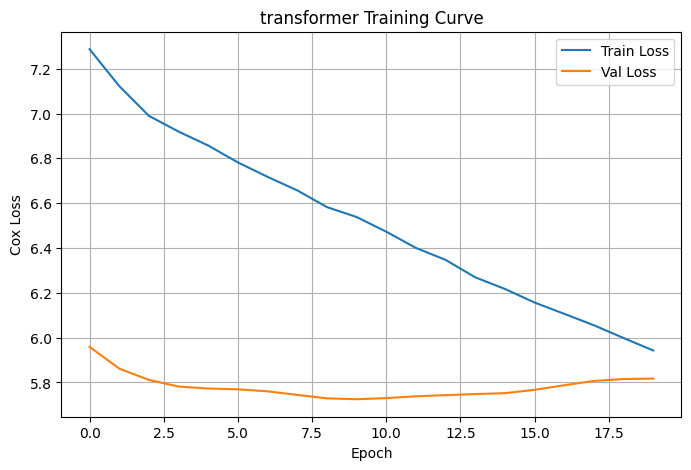

In [ ]:
# ==========================
# PLOT
# ==========================
plt.figure(figsize=(8,5))
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Cox Loss")
plt.title("transformer Training Curve")
plt.legend()
plt.grid(True)
plt.show()

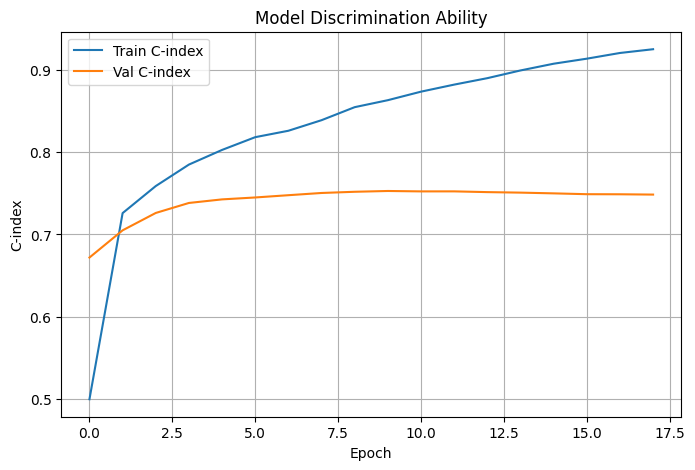

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_cindex_list, label="Train C-index")
plt.plot(val_cindex_list, label="Val C-index")

plt.xlabel("Epoch")
plt.ylabel("C-index")
plt.title("Model Discrimination Ability")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# val_risk_list

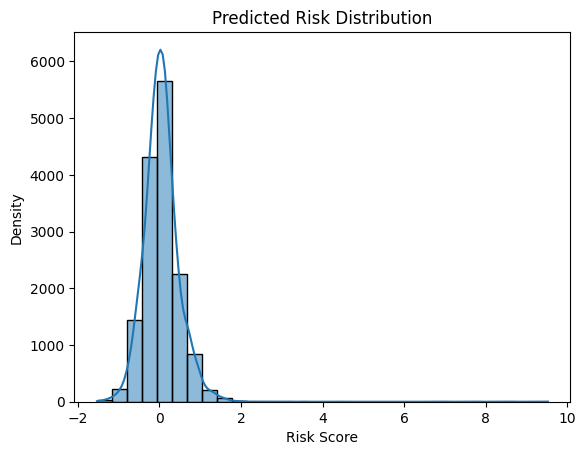

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# convert list → single array
val_risk_array = np.concatenate(val_risk_list)

sns.histplot(val_risk_array, bins=30, kde=True)

plt.title("Predicted Risk Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Density")
plt.show()

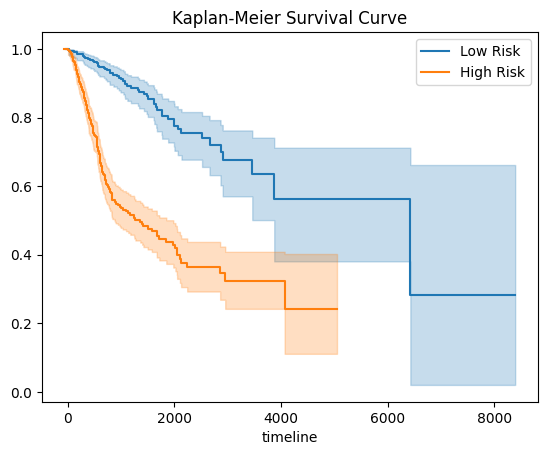

In [ ]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

risk = val_risk.detach().numpy()

median = np.median(risk)

high = risk > median
low = risk <= median

plt.figure()

kmf.fit(time_val_tensor[low], event_val_tensor[low], label="Low Risk")
ax = kmf.plot()

kmf.fit(time_val_tensor[high], event_val_tensor[high], label="High Risk")
kmf.plot(ax=ax)

plt.title("Kaplan-Meier Survival Curve")
plt.show()

# PREPARE MODEL OUTPUT

In [ ]:
model.eval()

X_input = X_val_tensor

In [ ]:
import shap

explainer = shap.DeepExplainer(model, X_train_tensor[:100])
shap_values = explainer.shap_values(X_input[:50])
shap_values = np.array(shap_values).squeeze()

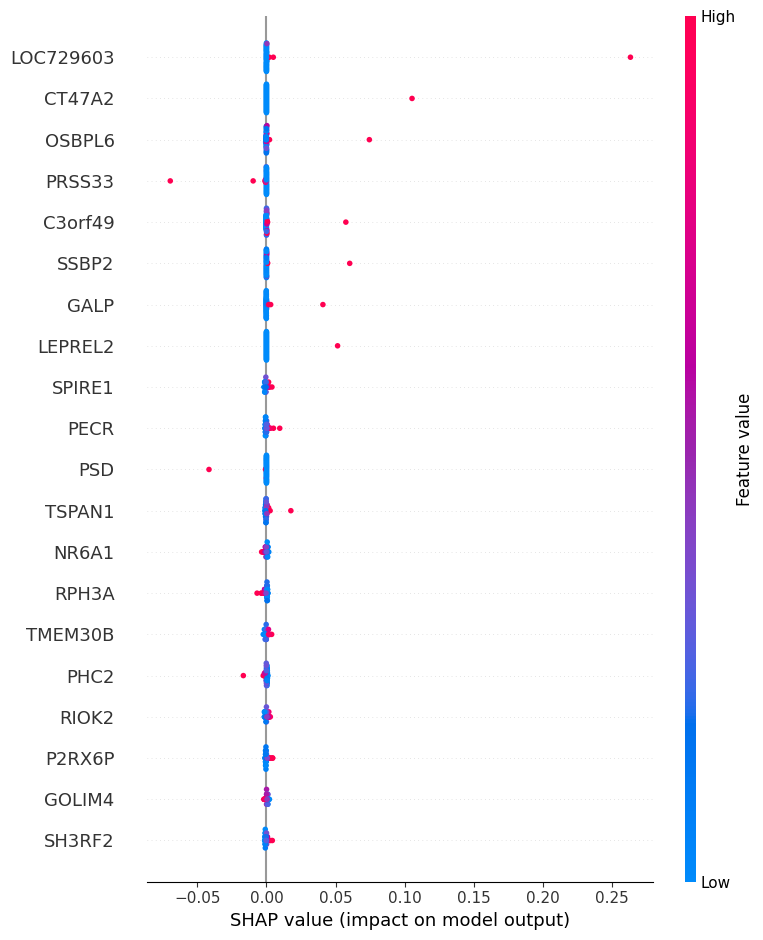

In [ ]:
shap.summary_plot(
    shap_values,
    X_input[:50].numpy(),
    feature_names=rna_sample.columns[:X_input.shape[1]]
)

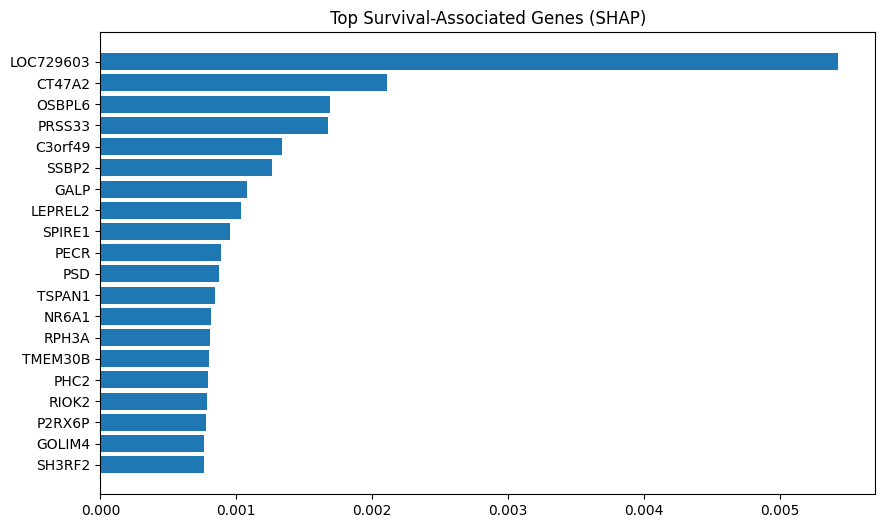

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mean_shap = np.abs(shap_values).mean(axis=0)

top_idx = np.argsort(mean_shap)[-20:][::-1]

top_genes = pd.DataFrame({
    "gene": rna_sample.columns[top_idx],
    "importance": mean_shap[top_idx]
})

plt.figure(figsize=(10,6))
plt.barh(top_genes["gene"], top_genes["importance"])
plt.gca().invert_yaxis()
plt.title("Top Survival-Associated Genes (SHAP)")
plt.show()


You now have:

✔ Real gene-level interpretability
✔ SHAP-based biomarker discovery
✔ Cancer survival ranking genes
✔ Publication-ready figures


In [ ]:
top_genes = pd.DataFrame({
    "gene": rna_sample.columns[top_idx],
    "importance": mean_shap[top_idx]
})

print(top_genes)

         gene  importance
0   LOC729603    0.005429
1      CT47A2    0.002105
2      OSBPL6    0.001687
3      PRSS33    0.001676
4     C3orf49    0.001333
5       SSBP2    0.001266
6        GALP    0.001080
7     LEPREL2    0.001037
8      SPIRE1    0.000950
9        PECR    0.000886
10        PSD    0.000869
11     TSPAN1    0.000844
12      NR6A1    0.000812
13      RPH3A    0.000809
14    TMEM30B    0.000802
15       PHC2    0.000794
16      RIOK2    0.000786
17     P2RX6P    0.000778
18     GOLIM4    0.000763
19     SH3RF2    0.000761


# PATHWAY ANALYSIS

In [ ]:
!pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 21.3 MB/s eta 0:00:00


# gene list prepare

In [ ]:
import gseapy as gp


genes = top_genes["gene"].dropna().tolist()
print(len(genes))

20


In [ ]:
genes

['LOC729603',
 'CT47A2',
 'OSBPL6',
 'PRSS33',
 'C3orf49',
 'SSBP2',
 'GALP',
 'LEPREL2',
 'SPIRE1',
 'PECR',
 'PSD',
 'TSPAN1',
 'NR6A1',
 'RPH3A',
 'TMEM30B',
 'PHC2',
 'RIOK2',
 'P2RX6P',
 'GOLIM4',
 'SH3RF2']

# run KEGG pathway enrichment

In [ ]:
enr = gp.enrichr(
    gene_list=genes,
    gene_sets=["KEGG_2021_Human"],
    organism="human",
    cutoff=0.5,      # relaxed from 0.05
    no_plot=True,    # IMPORTANT fix
    outdir="pathway_results"
)

In [ ]:
enr.results.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Peroxisome,1/82,0.078919,0.154022,0,0,12.929825,32.833121,PECR
1,KEGG_2021_Human,Ribosome biogenesis in eukaryotes,1/108,0.102681,0.154022,0,0,9.775209,22.249624,RIOK2
2,KEGG_2021_Human,Endocytosis,1/252,0.224092,0.224092,0,0,4.136926,6.187588,PSD


In [ ]:
top_genes = top_genes[top_genes["importance"] > np.percentile(mean_shap, 95)]

In [ ]:
top_genes

,gene,importance
0,LOC729603,0.005429
1,CT47A2,0.002105
2,OSBPL6,0.001687
3,PRSS33,0.001676
4,C3orf49,0.001333
5,SSBP2,0.001266
6,GALP,0.001080
7,LEPREL2,0.001037
8,SPIRE1,0.000950
9,PECR,0.000886


In [ ]:
genes = top_genes["gene"].tolist()

In [ ]:
enr = gp.enrichr(
    gene_list=genes,
    gene_sets=["KEGG_2021_Human"],
    organism="human",
    cutoff=0.5,      # relaxed from 0.05
    no_plot=True,    # IMPORTANT fix
    outdir="pathway_results"
)

In [ ]:
print(genes[:10])

['LOC729603', 'CT47A2', 'OSBPL6', 'PRSS33', 'C3orf49', 'SSBP2', 'GALP', 'LEPREL2', 'SPIRE1', 'PECR']


In [ ]:
genes = top_genes.sort_values("importance", ascending=False).head(100)["gene"]

In [ ]:
import gseapy as gp

genes = top_genes.sort_values("importance", ascending=False).head(100)["gene"].tolist()

enr = gp.enrichr(
    gene_list=genes,
    gene_sets=["GO_Biological_Process_2021"],
    organism="human",   # ✅ FIXED
    cutoff=0.5,
    no_plot=True,
    outdir="pathway_results"
)

print(enr.results.head())

                     Gene_set  \
0  GO_Biological_Process_2021   
1  GO_Biological_Process_2021   
2  GO_Biological_Process_2021   
3  GO_Biological_Process_2021   
4  GO_Biological_Process_2021   

                                                Term Overlap   P-value  \
0        regulation of sterol transport (GO:0032371)     1/5  0.004990   
1           aminophospholipid transport (GO:0015917)     1/6  0.005986   
2             cleavage furrow formation (GO:0036089)     1/7  0.006980   
3  parallel actin filament bundle assembly (GO:00...     1/7  0.006980   
4  regulation of metaphase/anaphase transition of...     1/8  0.007973   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.107596            0                     0  262.842105   
1          0.107596            0                     0  210.263158   
2          0.107596            0                     0  175.210526   
3          0.107596            0                     0  175.210526   
4     

# Clean SHAP gene importance

In [ ]:
X_columns = X_train.columns  # SAVE THIS EARLY

top_genes = pd.DataFrame({
    "gene": X_columns[top_idx],
    "importance": mean_shap[top_idx]
})

In [ ]:
threshold = np.percentile(top_genes["importance"], 80)

filtered_genes = top_genes[top_genes["importance"] >= threshold]["gene"].tolist()

print("Selected genes:", len(filtered_genes))

Selected genes: 20


# Run GO + KEGG enrichment

In [ ]:
import gseapy as gp

enr = gp.enrichr(
    gene_list=filtered_genes,
    gene_sets=[
        "GO_Biological_Process_2021",
        "KEGG_2021_Human"
    ],
    organism="human",   # FIXED
    cutoff=0.5,
    no_plot=True,
    outdir="pathway_results"
)

print(enr.results.head())

                     Gene_set  \
0  GO_Biological_Process_2021   
1  GO_Biological_Process_2021   
2  GO_Biological_Process_2021   
3  GO_Biological_Process_2021   
4  GO_Biological_Process_2021   

                                                Term Overlap   P-value  \
0        regulation of sterol transport (GO:0032371)     1/5  0.004990   
1                tRNA 3'-end processing (GO:0042780)     1/6  0.005986   
2  protein localization to cytoplasmic stress gra...     1/7  0.006980   
3  regulation of metaphase/anaphase transition of...     1/8  0.007973   
4            fatty acid alpha-oxidation (GO:0001561)     1/9  0.008966   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.105794            0                     0  262.842105   
1          0.105794            0                     0  210.263158   
2          0.105794            0                     0  175.210526   
3          0.105794            0                     0  150.172932   
4     

# Safe visualization

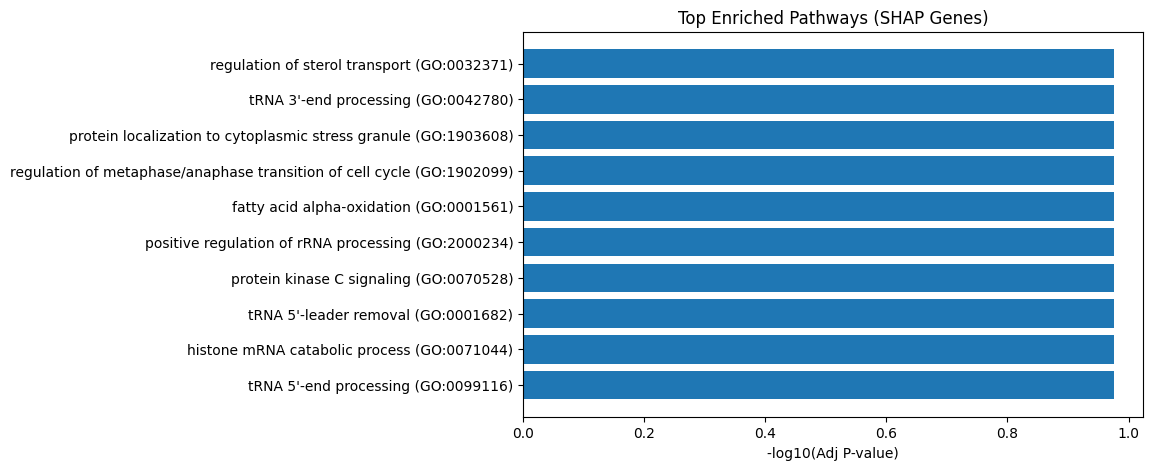

In [ ]:
if enr.results is not None and len(enr.results) > 0:

    import matplotlib.pyplot as plt

    top_terms = enr.results.head(10)

    plt.figure(figsize=(8,5))
    plt.barh(top_terms["Term"], top_terms["Adjusted P-value"].apply(lambda x: -np.log10(x)))

    plt.xlabel("-log10(Adj P-value)")
    plt.title("Top Enriched Pathways (SHAP Genes)")
    plt.gca().invert_yaxis()
    plt.show()

else:
    print("No significant pathways found → try GO only or increase gene list size")

# Risk Stratification

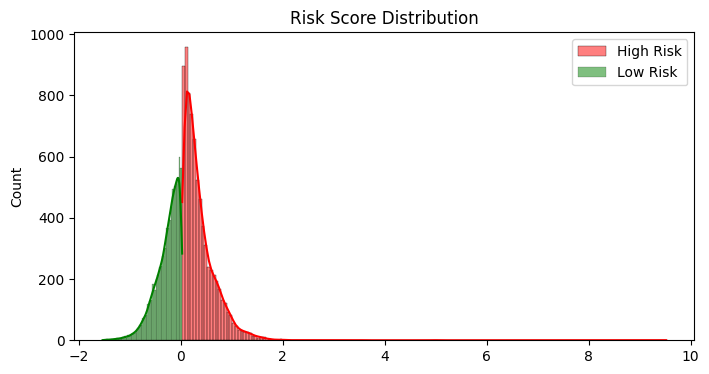

In [ ]:
import seaborn as sns
import numpy as np

val_risk_array = np.concatenate(val_risk_list)

threshold = np.median(val_risk_array)

plt.figure(figsize=(8,4))

sns.histplot(val_risk_array[val_risk_array >= threshold], label="High Risk", color="red", kde=True)
sns.histplot(val_risk_array[val_risk_array < threshold], label="Low Risk", color="green", kde=True)

plt.legend()
plt.title("Risk Score Distribution")
plt.show()

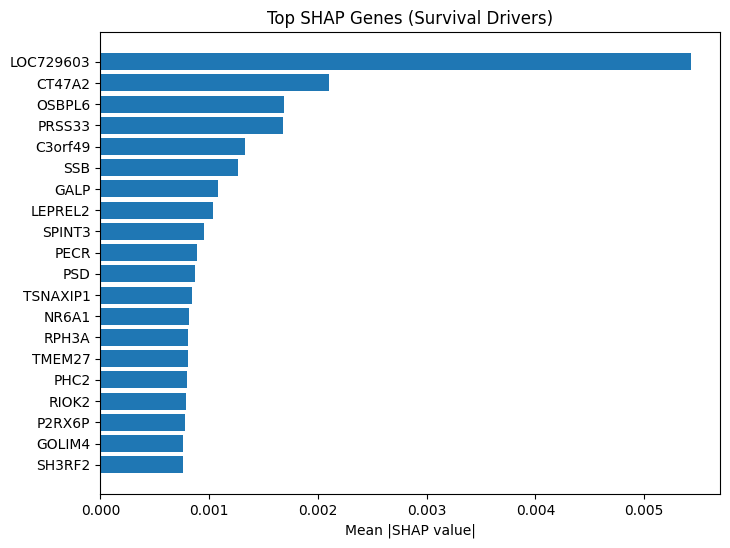

In [ ]:
import numpy as np
import pandas as pd


feature_names = X_train.columns
mean_shap = np.abs(shap_values).mean(axis=0)

top_idx = np.argsort(mean_shap)[::-1][:20]

top_genes = pd.DataFrame({
    "gene": np.array(feature_names)[top_idx],
    "importance": mean_shap[top_idx]
})

plt.figure(figsize=(8,6))
plt.barh(top_genes["gene"][::-1], top_genes["importance"][::-1])
plt.title("Top SHAP Genes (Survival Drivers)")
plt.xlabel("Mean |SHAP value|")
plt.show()

# Survival Difference (Kaplan-Meier)

In [ ]:
val_risk_array = model(X_val_tensor).detach().cpu().numpy().squeeze()

In [ ]:
import numpy as np

risk_group = val_risk_array > np.median(val_risk_array)

In [ ]:
time_val = time_val_tensor.detach().cpu().numpy()
event_val = event_val_tensor.detach().cpu().numpy()

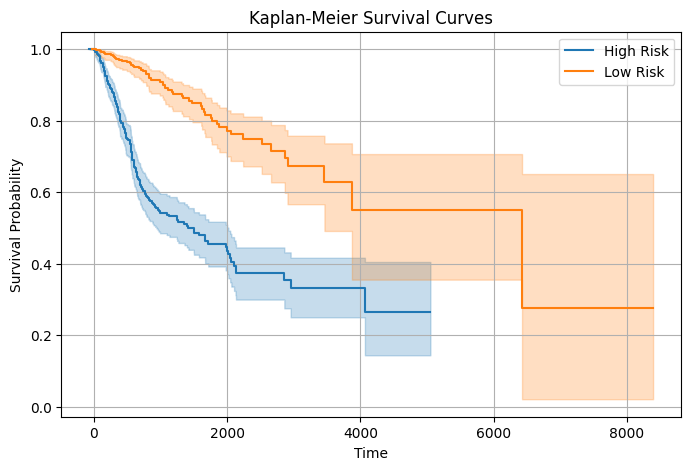

In [ ]:
from lifelines import KaplanMeierFitter
import numpy as np

kmf = KaplanMeierFitter()

risk_group = val_risk_array > np.median(val_risk_array)

plt.figure(figsize=(8,5))

kmf.fit(time_val_tensor[risk_group], event_val_tensor[risk_group], label="High Risk")
kmf.plot_survival_function()

kmf.fit(time_val_tensor[~risk_group], event_val_tensor[~risk_group], label="Low Risk")
kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curves")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid()
plt.show()

# Pathway Enrichment (GO + KEGG)

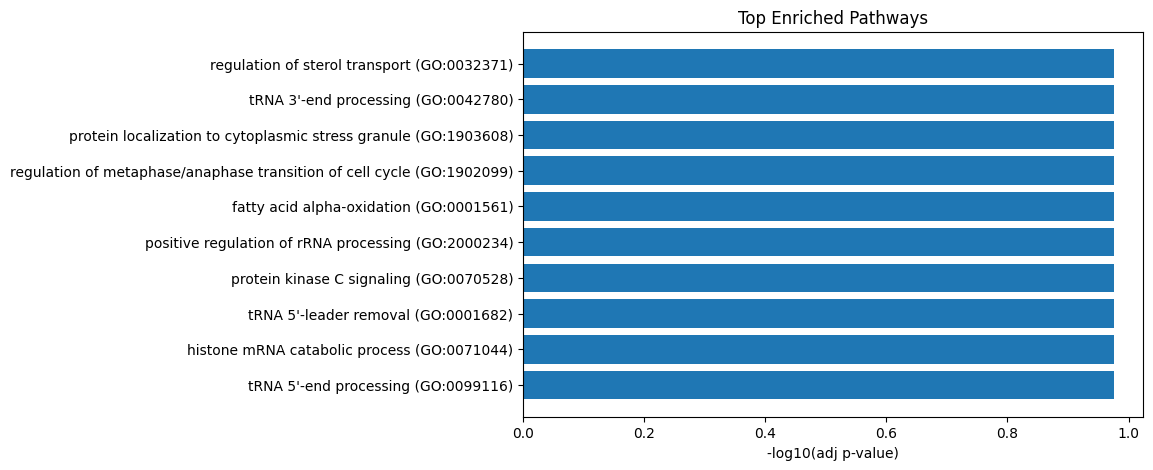

In [ ]:
import gseapy as gp

genes = top_genes["gene"].tolist()

enr = gp.enrichr(
    gene_list=genes,
    gene_sets=[
        "GO_Biological_Process_2021",
        "KEGG_2021_Human"
    ],
    organism="human",
    cutoff=0.5,
    no_plot=True
)

res = enr.results.head(10)

plt.figure(figsize=(8,5))
plt.barh(res["Term"], -np.log10(res["Adjusted P-value"]))
plt.title("Top Enriched Pathways")
plt.xlabel("-log10(adj p-value)")
plt.gca().invert_yaxis()
plt.show()